## Аминокислотные последовательности антител

<img src="https://i0.wp.com/www.blopig.com/blog/wp-content/uploads/2013/07/Antibody1.png?ssl=1" style="background:white" width="600"/>

Как и любые белки́, [антитела](https://ru.wikipedia.org/wiki/%D0%90%D0%BD%D1%82%D0%B8%D1%82%D0%B5%D0%BB%D0%B0) состоят из [аминокислот](https://shorturl.at/Wc6V4), соединённых пептидными связями.

Каждой аминокислоте соответствует однобуквенный код (A - аланин, C - цистеин, D - аспартат, и т.д.), поэтому мы можем компактно записывать первичную структуру белков (то есть просто цепочку аминокислот) в виде строк.

Сегодня нам предстоит решить две задачи:
1. Обучить модель-классификатор, позволяющую по аминокислотной последовательности понять, из какого животного было получено антитело
2. Обучить модель-генератор новых антител с условием на биологический вид

#### Подготовим данные

В нашем наборе данных присутствуют антитела (точнее - небольшие фрагменты тяжелых цепей антител, VH-домены, непосредственно участвующие в связывании инородных молекул - антигенов), полученные из образцов пяти биологических видов: человек, макака-резус, мышь, кролик и верблюд.

In [35]:
import pandas as pd

antibodies = pd.read_csv("/content/antibodies.csv").sample(frac=1.0)
antibodies.head(10)

,sequence,species
2780,SVKVSCKASGYIFTTYYMHWVRQAPGQGLEWMGRINPSGGDTSYTQ...,Mouse
856,QVQLKQSGAELVRPGASVKLSCKASGYTFSDYYINWVKQRPGQGLE...,Human
2099,SVKVSCKTSGYTFTGHYIHWVRQAPGQGLEWMGRINPNSGVTSYAQ...,Mouse
4966,VRQAPGKGLEWIACIDTSNGDTDYANWPKGRFTISKASSTTVTLQM...,Rabbit
408,QVQLKESGPGLVAPSQSLSITCTVSGFSLTTYAITWVRQPPGKGLE...,Human
2267,SVKVSCKASGYTFNDYAIHWVRQAPGQGLEWVGWINTSNGNTRHSQ...,Mouse
724,EVQLQQSGAELVRPGASVKLSCTASGFNIKDDYMHWVKQRPEQGLE...,Human
772,QVQLQQSGAELVKPGASVKLSCKASGYTFTEYTIHWVKQRSGQGLE...,Human
3255,EVQLVESGGGLVQPGGSLRLSCAASGFTFSGYGFHWVRQARGKGLE...,Rhesus
3139,QVQLQESGPGLVKPSETLSLTCAVSGASISSYWCSWIRQAPGKGLE...,Rhesus


Создадим словари для аминокислот, специальных токенов и биологических видов:

In [36]:
SPECIAL_TOKENS = "_?\n"
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWYX"
VOCAB = {char: i for i, char in enumerate(SPECIAL_TOKENS + AMINO_ACIDS)}
SPECIES = {name: i for i, name in enumerate(sorted(antibodies["species"].unique()))}
SPECIES

{'Camel': 0, 'Human': 1, 'Mouse': 2, 'Rabbit': 3, 'Rhesus': 4}

In [37]:
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, random_split


class AntibodiesDataset(Dataset):
    def __init__(self, df: pd.DataFrame) -> None:
        self.sequences = [
            [1] + [VOCAB[char] for char in s] + [2] for s in df["sequence"]
        ]
        self.labels = [SPECIES[label] for label in df["species"]]

    def __getitem__(self, index: int) -> tuple[list[int], int]:
        return self.sequences[index], self.labels[index]

    def __len__(self) -> int:
        return len(self.sequences)

    @staticmethod
    def collate_fn(batch: list[tuple[list[int], int]]) -> tuple[Tensor, Tensor]:
        encoded, lang_ids = zip(*batch)
        max_len = max(map(len, encoded))
        x = torch.zeros((len(encoded), max_len), dtype=int)
        for i, seq in enumerate(encoded):
            x[i, : len(seq)] = torch.tensor(seq)

        return x, torch.tensor(list(lang_ids))


labels = sorted(antibodies["species"].unique())
dataset = AntibodiesDataset(antibodies)
train_dataset, test_dataset = random_split(
    dataset, [4500, 500], torch.Generator().manual_seed(42)
)
print("Train size: ", len(train_dataset))
print("Test size: ", len(test_dataset))

Train size:  4500
Test size:  500


In [38]:
train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, collate_fn=dataset.collate_fn
)
test_loader = DataLoader(
    test_dataset, batch_size=32, shuffle=False, collate_fn=dataset.collate_fn
)

#### Задание 1 (6 баллов). Классификация антител по биологическим видам

Мы начнём с нашей рекуррентной ячейки с последней практики:

In [39]:
class RNNCell(nn.Module):
    """
    (x_{t}, h_{t-1}) -> h_{t}
    """

    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim + hidden_dim, hidden_dim)

    def forward(self, x: Tensor, h: Tensor) -> Tensor:
        # x: B x input_dim
        # h: B x hidden_dim
        h = torch.cat([x, h], dim=1)
        h = self.linear(h)
        return F.tanh(h)

**1.1. (1 балл)** Реализуйте архитектуру модели, которая по входной последовательности будет давать вероятностное распределение над биологическими видами.
Она даже немного проще, чем модель для генерации: линейный блок-классификатор мы применяем только к последнему скрытому состоянию (когда вся последовательность обработана).

**1.2. (2 балла)** Обучите модель в течение 10-50 эпох, постройте графики точности классифкации для обучающей и тестовой выборок.

**1.3. (3 балла)** Реализуйте другой вид рекуррентной ячейки (GRU или LSTM, см. практику), обучите модель на его основе, выведите графики точности. Как изменилась точность модели и скорость обучения?


Указание: используйте небольшие модели, с размером скрытого слоя 64

In [40]:
class RNN(nn.Module):
    def __init__(self, rnn, vocab_size: int, hidden_dim: int, n_classes) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_dim)
        self.p_embed = nn.Embedding(n_classes, hidden_dim)
        self.init_h = nn.Parameter(data=torch.randn(1, hidden_dim))

        self.rnn = rnn
        self.lm_head = nn.Linear(hidden_dim, vocab_size)
        self.cl = nn.Linear(hidden_dim, n_classes)


    def forward(self, x: Tensor, pr = None) -> Tensor:
        # x: B x T
        # embed(x): B x T -> B x T x hidden_dim
        B, T = x.shape

        x = self.embed(x)  # B x T x hidden_dim
        pr = self.p_embed(pr) if pr is not None else None

        h = self.init_h.expand((B, -1)) # B x hidden_dim


        logits = [] # T x B x V
        for t in range(T):
            xt = x[:, t, :]
            if pr is None:
              h = self.rnn.forward(xt, h)  # B x hidden
            else:
              h = self.rnn.forward(xt, pr, h)
            y = self.lm_head(h).unsqueeze(1)  # B x 1 x hidden
            logits.append(y)
            # save prediction for step t + 1

        # lm_head: B x T x hidden -> B x T x V
        return torch.cat(logits, dim=1), self.cl(h)

In [41]:
hidden_dim = 64
model = RNN(
    rnn = RNNCell(hidden_dim, hidden_dim),
    vocab_size=len(VOCAB),
    hidden_dim=hidden_dim,
    n_classes=len(SPECIES)
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [42]:
def acc(m, loader):
  cor, all = 0, 0
  for t, labels in loader:
    with torch.no_grad():
      _, p = m.forward(t)
      preds = torch.argmax(p, axis = 1)
      cor += (preds == labels).sum()
      all += len(preds)
  return cor / all


In [43]:
train, test = [], []

for epoch in range(15):
    print('==== epoch {} ===='.format(epoch))
    for tokens, labels in train_loader:
        logits, p = model.forward(tokens)  # B x T x V
        loss = F.cross_entropy(p, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    test_a, tr_a = acc(model, test_loader), acc(model, train_loader)
    train.append(tr_a)
    test.append(test_a)
    print(loss.cpu().detach())
    print(test_a, tr_a)

print(train)
print(test)

==== epoch 0 ====
tensor(2.0920)
tensor(0.3280) tensor(0.3162)
==== epoch 1 ====
tensor(1.7416)
tensor(0.2540) tensor(0.2751)
==== epoch 2 ====
tensor(1.3778)
tensor(0.4160) tensor(0.3916)
==== epoch 3 ====
tensor(1.5892)
tensor(0.4340) tensor(0.4089)
==== epoch 4 ====
tensor(1.2997)
tensor(0.4420) tensor(0.4364)
==== epoch 5 ====
tensor(1.4484)
tensor(0.4180) tensor(0.4311)
==== epoch 6 ====
tensor(1.5042)
tensor(0.4320) tensor(0.4322)
==== epoch 7 ====
tensor(1.7157)
tensor(0.4400) tensor(0.4344)
==== epoch 8 ====
tensor(1.2716)
tensor(0.4520) tensor(0.4496)
==== epoch 9 ====
tensor(0.9582)
tensor(0.4340) tensor(0.4358)
==== epoch 10 ====
tensor(1.2890)
tensor(0.3840) tensor(0.4218)
==== epoch 11 ====
tensor(1.1514)
tensor(0.3940) tensor(0.4162)
==== epoch 12 ====
tensor(1.1125)
tensor(0.4580) tensor(0.4467)
==== epoch 13 ====
tensor(0.9503)
tensor(0.4360) tensor(0.4398)
==== epoch 14 ====
tensor(1.2286)
tensor(0.4500) tensor(0.4436)
[tensor(0.3162), tensor(0.2751), tensor(0.3916), t

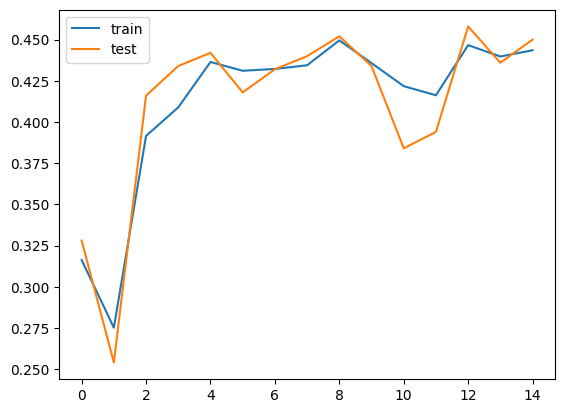

In [44]:
import matplotlib.pyplot as plt

plt.plot(train, label="train")
plt.plot(test, label="test")

plt.legend()
plt.show()

In [61]:
class GRU(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.lz, self.lh = (nn.Linear(input_dim + hidden_dim, hidden_dim, bias=False) for _ in range(2))

    def forward(self, x: Tensor, h: Tensor) -> Tensor:
        hx = torch.cat([x, h], dim=1)
        z, h_ = torch.sigmoid(self.lz(hx)), torch.sigmoid(self.lh(hx))
        return (1 - z) * h + z * F.tanh(h_)

In [62]:
hidden_dim = 64
model = RNN(
    rnn = GRU(hidden_dim, hidden_dim),
    vocab_size=len(VOCAB),
    hidden_dim=hidden_dim,
    n_classes=len(SPECIES)
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [63]:
train, test = [], []

for epoch in range(15):
    print('==== epoch {} ===='.format(epoch))
    for tokens, labels in train_loader:
        logits, p = model.forward(tokens)  # B x T x V
        loss = F.cross_entropy(p, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    test_a, tr_a = acc(model, train_loader), acc(model, test_loader)
    train.append(tr_a)
    test.append(test_a)
    print(loss.cpu())
    print(test_a, tr_a)

print(train)
print(test)

==== epoch 0 ====
tensor(1.3723, grad_fn=<NllLossBackward0>)
tensor(0.4193) tensor(0.4020)
==== epoch 1 ====
tensor(1.4708, grad_fn=<NllLossBackward0>)
tensor(0.4691) tensor(0.4680)
==== epoch 2 ====
tensor(1.0103, grad_fn=<NllLossBackward0>)
tensor(0.6038) tensor(0.5540)
==== epoch 3 ====
tensor(1.0471, grad_fn=<NllLossBackward0>)
tensor(0.6878) tensor(0.6720)
==== epoch 4 ====
tensor(0.5596, grad_fn=<NllLossBackward0>)
tensor(0.7931) tensor(0.7660)
==== epoch 5 ====
tensor(0.6331, grad_fn=<NllLossBackward0>)
tensor(0.8033) tensor(0.8020)
==== epoch 6 ====
tensor(0.5563, grad_fn=<NllLossBackward0>)
tensor(0.8362) tensor(0.8060)
==== epoch 7 ====
tensor(0.4075, grad_fn=<NllLossBackward0>)
tensor(0.8424) tensor(0.8300)
==== epoch 8 ====
tensor(0.2658, grad_fn=<NllLossBackward0>)
tensor(0.9042) tensor(0.9080)
==== epoch 9 ====
tensor(0.1817, grad_fn=<NllLossBackward0>)
tensor(0.9273) tensor(0.9280)
==== epoch 10 ====
tensor(0.6522, grad_fn=<NllLossBackward0>)
tensor(0.9387) tensor(0.9340

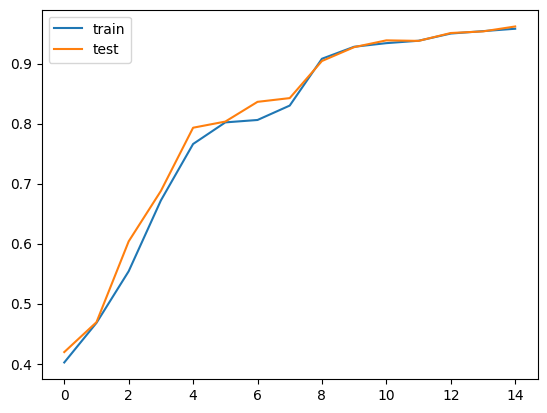

In [64]:
import matplotlib.pyplot as plt

plt.plot(train, label="train")
plt.plot(test, label="test")

plt.legend()
plt.show()

#### Задание 2 (8 баллов + 4 бонусных). Генерация антител

Поиграем за B-лимфоцит и попробуем создать новые антитела.

Модель - почти полная копия модели с практики, но есть дополнительное условие: теперь кроме текущего токена и предыдущего скрытого состояния пусть наша ячейка принимает ещё метку биологического вида, к которому должно относиться антитело, вроде такого:

In [49]:
class ConditionalRNNCell(nn.Module):
    """
    (x_{t}, h_{t-1}, c) -> h_{t}
    """
    def __init__(self, input_dim: int, hidden_dim: int, class_dim) -> None:
        super().__init__()
        self.linear = nn.Linear(input_dim+hidden_dim+class_dim, hidden_dim)

    def forward(self, x: Tensor, c: Tensor, h: Tensor) -> Tensor:
        # x: B x input_dim: эмбеддинг последнего токен
        # c: B x class_dim: эмбеддинг биологического вида
        # h: B x hidden_dim: последнее скрытое состояние
        h = torch.cat([x, c, h], dim=1)
        h = self.linear(h)
        return F.tanh(h)

In [50]:
hidden_dim = 64
model = RNN(
    rnn = ConditionalRNNCell(hidden_dim, hidden_dim, hidden_dim),
    vocab_size=len(VOCAB),
    hidden_dim=hidden_dim,
    n_classes=len(SPECIES)
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [51]:
ls = []

for epoch in range(15):
    print('==== epoch {} ===='.format(epoch))
    for tokens, labels in train_loader:
        logits, p = model.forward(tokens, labels)  # B x T x V
        loss = F.cross_entropy(
          logits[:, :-1].reshape(-1, len(VOCAB)),
          tokens[:, 1:].reshape(-1),
        )
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(loss.cpu().detach())
    ls.append(loss.cpu().detach())
print(ls)


==== epoch 0 ====
tensor(1.9750)
==== epoch 1 ====
tensor(1.4367)
==== epoch 2 ====
tensor(1.3694)
==== epoch 3 ====
tensor(1.3865)
==== epoch 4 ====
tensor(1.1363)
==== epoch 5 ====
tensor(1.1148)
==== epoch 6 ====
tensor(1.0374)
==== epoch 7 ====
tensor(0.9819)
==== epoch 8 ====
tensor(0.9479)
==== epoch 9 ====
tensor(1.0622)
==== epoch 10 ====
tensor(1.0060)
==== epoch 11 ====
tensor(0.9058)
==== epoch 12 ====
tensor(1.1869)
==== epoch 13 ====
tensor(0.9124)
==== epoch 14 ====
tensor(0.9746)
[tensor(1.9750), tensor(1.4367), tensor(1.3694), tensor(1.3865), tensor(1.1363), tensor(1.1148), tensor(1.0374), tensor(0.9819), tensor(0.9479), tensor(1.0622), tensor(1.0060), tensor(0.9058), tensor(1.1869), tensor(0.9124), tensor(0.9746)]


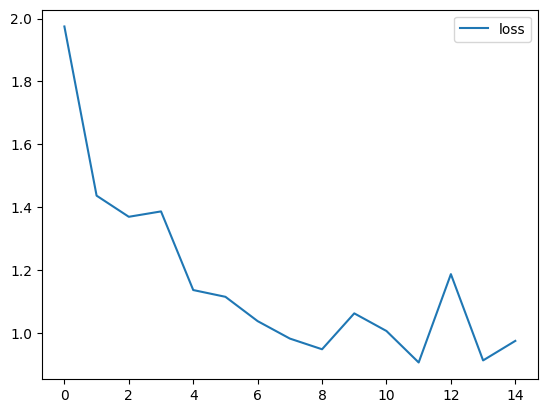

In [52]:
plt.plot(ls, label="loss")
plt.legend()

plt.show()

In [53]:
@torch.no_grad()
def generate(model: RNN, idx: Tensor, max_new_tokens: int, labels) -> Tensor:
    # idx: B x T
    for t in range(max_new_tokens):
        logits = model.forward(idx, labels)[0][:, -1]  # B x T x V
        probs = F.softmax(logits, dim=1)  # B x V
        new_token = torch.multinomial(probs, 1)
        idx = torch.cat([idx, new_token], dim=1)

    return idx

INV_VOCAB = {i: j for j, i in VOCAB.items()}


def batch_decode(out_tokens: Tensor) -> list[str]:
    decoded_strings = []
    for x in out_tokens:
        decoded_strings.append(''.join([INV_VOCAB[c] for c in x.cpu().tolist()]))

    return decoded_strings


In [54]:
from Bio.Align import PairwiseAligner


def get_sequence_score(query_sequence: str) -> float:
    references = [
        "QVQLQQPGAELVKPGASVKMSCKAS_WITWVKQRPGQGLEWIGDI_TNYNEKFKTKATLTVDTSSSTAYMQLSSLTSEDSAVYYCAR_WGQGTSVTVSS",
        "EVKLEESGGGLVQPGGSMKLSCAAS_WMDWVRQSPEKGLEWVAEI_TYYAESVKGRFTISRDDSKSSVYLQMNSLRAEDTGIYYCTA_WGQGTLVTVSA",
        "HVQLVESGGGSVQPGGSLRLSCTVS_CMGWFRRAPGKEREKVATL_TSYADSVKGRFAISQDPAKNTLWLQMNSLKPEDSATYYCAA_SSRGTQVTVS",
        "QVQLVESGGGSVQAGGSLKLSCAAS_CMGWSRQAPGKGREGVARI_TAYADSVKGRFTISHDSIKNTLYLQMNSLRPEDTAKYYCAA_WGQGTQVTV",
        "QSLEESGGDLVKPGASLTLTCTAS_YMCWVRQAPGKGLEWIACI_TYYASWAKGRFTISKTSSTTVTLQMTSLTAADTATYFCAS_WGQGTLVTVS",
        "QEQLVESGGGLVKPGASLTLTCKAS_VMCWVRQAPGKGLEWIACI_SVYASWAKGRSTISRTSSTTVTLQMTSLTAADTATYFCAR_RGPGTLVTVS",
        "SVKVSCKAS_WIQWVRQAPGQGLEWMGWM_TTYSPKFQGRVSMTSDKSITTAYLELRGLTSDDTAVYSCAR_WGQGTLITVTS",
    ]
    max_score = 0.0
    for ref in map(lambda s: s.replace("_", ""), references):
        alignment = PairwiseAligner().align(query_sequence, ref)[0]
        n_matches = sum(
            1 for i in range(alignment.length) if alignment[0][i] == alignment[1][i]
        )
        max_score = max(max_score, n_matches / len(ref))

    return max_score

In [55]:
for i in range (5):
  good = 0
  labels = torch.tensor([i] * 20)

  samples = generate(model, idx=torch.full(size=(20, 1), fill_value=1, dtype=int), max_new_tokens=40,labels=labels)

  for s in batch_decode(samples):
    if get_sequence_score(s) > 0.55:
      good += 1

  print ("{} / 20 is good".format(good)) # :(

0 / 20 is good
0 / 20 is good
0 / 20 is good
0 / 20 is good
0 / 20 is good


**2.1. (2 балла)** Реализуйте архитектуру модели для генерации антител символ за символом

**2.2. (2 балла)** Обучите модель в течение 10-50 эпох, постройте графики функции ошибки.

**2.3. (4 балла)** Сгенерируйте с помощью модели по 20 антител для каждого биологического вида в отдельных ячейках, выведите их в ноутбуке. Воспользуйтесь функцией `get_sequence_score` (ниже), чтобы посчитать сходство ваших антител с природными (вернее - очень грубую оценку). Посчитайте, сколько антител из сгенерированных вами имеют оценку 0.55 и выше для каждого биологического вида.

**2.4. (Бонус 4 балла)** Повторите пункты 2.2 и 2.3, но используйте другой тип рекуррентной ячейки (GRU или LSTM).


In [56]:
! pip install biopython==1.84

In [57]:
from Bio.Align import PairwiseAligner


def get_sequence_score(query_sequence: str) -> float:
    references = [
        "QVQLQQPGAELVKPGASVKMSCKAS_WITWVKQRPGQGLEWIGDI_TNYNEKFKTKATLTVDTSSSTAYMQLSSLTSEDSAVYYCAR_WGQGTSVTVSS",
        "EVKLEESGGGLVQPGGSMKLSCAAS_WMDWVRQSPEKGLEWVAEI_TYYAESVKGRFTISRDDSKSSVYLQMNSLRAEDTGIYYCTA_WGQGTLVTVSA",
        "HVQLVESGGGSVQPGGSLRLSCTVS_CMGWFRRAPGKEREKVATL_TSYADSVKGRFAISQDPAKNTLWLQMNSLKPEDSATYYCAA_SSRGTQVTVS",
        "QVQLVESGGGSVQAGGSLKLSCAAS_CMGWSRQAPGKGREGVARI_TAYADSVKGRFTISHDSIKNTLYLQMNSLRPEDTAKYYCAA_WGQGTQVTV",
        "QSLEESGGDLVKPGASLTLTCTAS_YMCWVRQAPGKGLEWIACI_TYYASWAKGRFTISKTSSTTVTLQMTSLTAADTATYFCAS_WGQGTLVTVS",
        "QEQLVESGGGLVKPGASLTLTCKAS_VMCWVRQAPGKGLEWIACI_SVYASWAKGRSTISRTSSTTVTLQMTSLTAADTATYFCAR_RGPGTLVTVS",
        "SVKVSCKAS_WIQWVRQAPGQGLEWMGWM_TTYSPKFQGRVSMTSDKSITTAYLELRGLTSDDTAVYSCAR_WGQGTLITVTS",
    ]
    max_score = 0.0
    for ref in map(lambda s: s.replace("_", ""), references):
        alignment = PairwiseAligner().align(query_sequence, ref)[0]
        n_matches = sum(
            1 for i in range(alignment.length) if alignment[0][i] == alignment[1][i]
        )
        max_score = max(max_score, n_matches / len(ref))

    return max_score

In [58]:
get_sequence_score("HVQLVESGGGSVQAGGSLRLSCSLTGTRLSINSRGTGGTF")

0.35106382978723405

In [59]:
get_sequence_score(
    "EVQLVESGGGLVQPGGSLRLSCAASGFTFSDDGMSWVRQAPGKGLEWVAVISSDGSQKSNADSVRDRFTISKDNSKNMLYLQMNNLRLEDTAVYFCTTFSYWGQGVQVTVSS"
)

0.7340425531914894